# Ce notebook permet de préparer la table et les variables pour réaliser le score de churn du TP

# Sommaire

1. [Import](#sect1)
2. [Nettoyage des données](#sect2)
3. [Export des données pour le notebook "ModelesPridictifChurn"](#sect3)
4. [Analyse descriptive sur les données normalisées](#sect4)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt 
import rich 
from rich.pretty import pprint

pd.set_option("display.max_columns", None)
repertoire = "../data/"
os.chdir(repertoire)

# 1. Import <a name="sect1" ></a> 

### Data -> données de score d'attrition dans le secteur des Telco

In [2]:
churn_df = pd.read_csv('churn.csv')

In [3]:
churn_df.shape

(3333, 21)

In [4]:
churn_df.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [5]:
churn_df.columns

Index(['State', 'Account Length', 'Area Code', 'Phone', 'Int'l Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls', 'Churn?'],
      dtype='str')

In [6]:
churn_df.dtypes

State                 str
Account Length      int64
Area Code           int64
Phone                 str
Int'l Plan            str
VMail Plan            str
VMail Message       int64
Day Mins          float64
Day Calls           int64
Day Charge        float64
Eve Mins          float64
Eve Calls           int64
Eve Charge        float64
Night Mins        float64
Night Calls         int64
Night Charge      float64
Intl Mins         float64
Intl Calls          int64
Intl Charge       float64
CustServ Calls      int64
Churn?                str
dtype: object

# 2. Nettoyage des données <a name="sect2" ></a> 

In [7]:
# Types des colonnes pour transformation
feat_quali = ['Area Code']
feat_quanti = [ 'Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls']
feat_bool = ["Int'l Plan",'VMail Plan']
target = "Churn?"

In [8]:
# Area Code -> Catégorielle
churn_df['Area Code'] = churn_df['Area Code'].astype(str)


In [9]:
# Transformation de la variable Target en numérique
churn_df['Churn?'] = churn_df['Churn?'].map({"False.": 0, "True.": 1})


y = churn_df['Churn?']
# 14,5% de Churners
print(y.mean())

0.14491449144914492


In [10]:
# Transformation des booléens en Numpy Bool
for col in feat_bool:
        churn_df[col] = churn_df[col] == "yes"


In [11]:
type(churn_df["Int'l Plan"].iloc[0])

numpy.bool

### Analyse de corrélation sur données mixtes

Notre dataset contient des variables de types différents : **numériques** et **catégorielles**. Cela rend l’analyse des corrélations non triviale, car les méthodes classiques comme le coefficient de Pearson ne s’appliquent qu’aux variables numériques.

Pour contourner cette limite, nous utilisons la fonction `associations()` du package `dython`, qui applique automatiquement la mesure adaptée selon les types de variables :

- **Numérique ↔ Numérique** : coefficient de Pearson  
- **Catégorielle ↔ Catégorielle** : V de Cramér ou U de Theil  
- **Numérique ↔ Catégorielle** : ratio de corrélation (η²)

Cela permet d’obtenir une matrice de corrélation complète, adaptée aux jeux de données hétérogènes.


In [12]:
from dython.nominal import associations

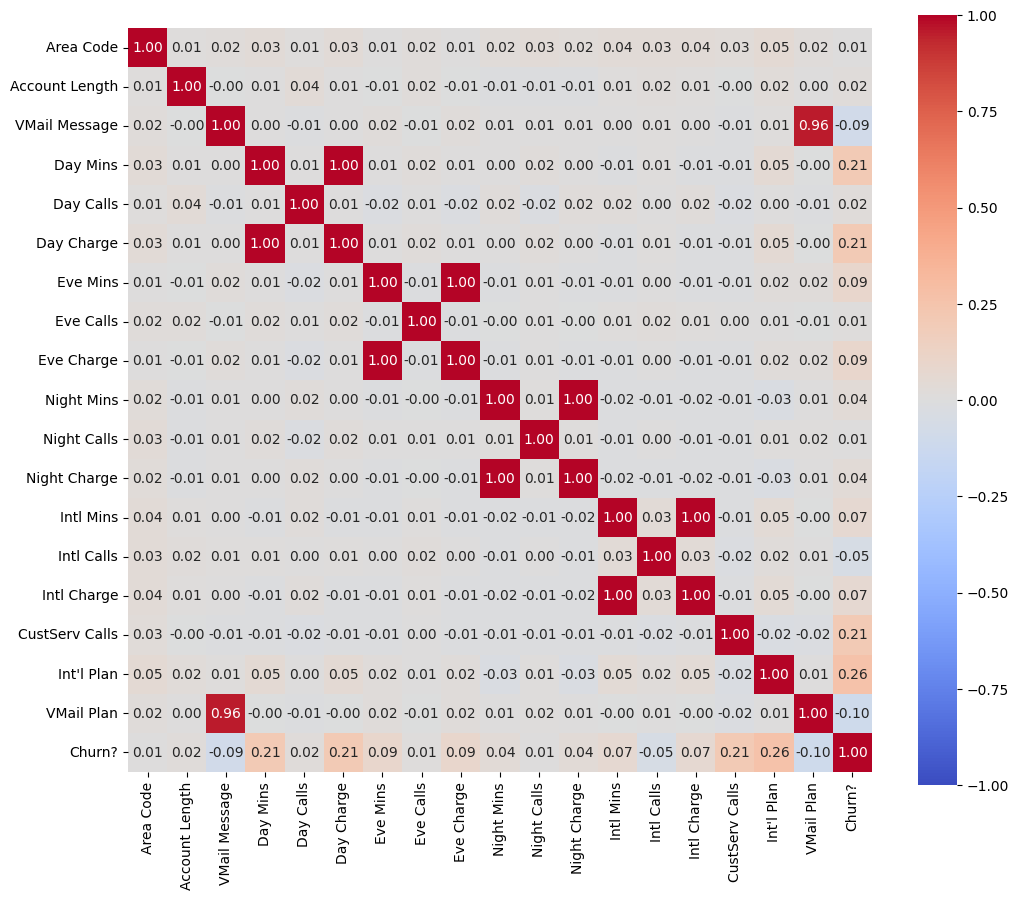

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
assoc = associations(churn_df[feat_quali + feat_quanti + feat_bool + [target]],
                     nominal_columns='auto',
                     numerical_columns='auto',
                     figsize=(12,10),
                     annot=True,
                     cmap='coolwarm',
                     ax=ax)


In [14]:
stats = churn_df.describe(include='all')
stats.T
# churn_df[feat_quanti + [target] ].corr()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,3333,51,WV,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Length,3333.0,NaN,NaN,NaN,101.064806,39.822106,1.0,74.0,101.0,127.0,243.0
Area Code,3333,3,415,1655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phone,3333,3333,382-4657,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Int'l Plan,3333,2,False,3010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VMail Plan,3333,2,False,2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VMail Message,3333.0,NaN,NaN,NaN,8.09901,13.688365,0.0,0.0,0.0,20.0,51.0
Day Mins,3333.0,NaN,NaN,NaN,179.775098,54.467389,0.0,143.7,179.4,216.4,350.8
Day Calls,3333.0,NaN,NaN,NaN,100.435644,20.069084,0.0,87.0,101.0,114.0,165.0
Day Charge,3333.0,NaN,NaN,NaN,30.562307,9.259435,0.0,24.43,30.5,36.79,59.64


##### Analyse de quelques variables catégorielles 

In [15]:
# Analyse des liens entre la variable catégorielle "Area Code" afin de recoder : 
# semble ne pas avoir de lien mais conservation de la colonne pour des liens non binaires
print(pd.crosstab(churn_df['Area Code'],y, normalize='index'))


Churn?            0         1
Area Code                    
408        0.854415  0.145585
415        0.857402  0.142598
510        0.851190  0.148810


In [16]:
# par contre les deux var qui indiquent si le client paie pour un service international ou VM sont très discriminantes
print(pd.crosstab(churn_df["Int'l Plan"],y, normalize='index'))
print(pd.crosstab(churn_df["VMail Plan"],y, normalize='index'))

Churn?             0         1
Int'l Plan                    
False       0.885050  0.114950
True        0.575851  0.424149
Churn?             0         1
VMail Plan                    
False       0.832849  0.167151
True        0.913232  0.086768


In [17]:
churn_df['State'].value_counts()

State
WV    106
MN     84
NY     83
AL     80
OH     78
WI     78
OR     78
VA     77
WY     77
CT     74
ID     73
VT     73
MI     73
TX     72
UT     72
IN     71
KS     70
MD     70
NJ     68
MT     68
NC     68
CO     66
WA     66
NV     66
MA     65
RI     65
MS     65
AZ     64
MO     63
FL     63
NM     62
ME     62
ND     62
OK     61
NE     61
DE     61
SC     60
SD     60
KY     59
IL     58
NH     56
AR     55
GA     54
DC     54
HI     53
TN     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [18]:
# étude du state
print(pd.crosstab(churn_df['State'],y,normalize='index'))

Churn?         0         1
State                     
AK      0.942308  0.057692
AL      0.900000  0.100000
AR      0.800000  0.200000
AZ      0.937500  0.062500
CA      0.735294  0.264706
CO      0.863636  0.136364
CT      0.837838  0.162162
DC      0.907407  0.092593
DE      0.852459  0.147541
FL      0.873016  0.126984
GA      0.851852  0.148148
HI      0.943396  0.056604
IA      0.931818  0.068182
ID      0.876712  0.123288
IL      0.913793  0.086207
IN      0.873239  0.126761
KS      0.814286  0.185714
KY      0.864407  0.135593
LA      0.921569  0.078431
MA      0.830769  0.169231
MD      0.757143  0.242857
ME      0.790323  0.209677
MI      0.780822  0.219178
MN      0.821429  0.178571
MO      0.888889  0.111111
MS      0.784615  0.215385
MT      0.794118  0.205882
NC      0.838235  0.161765
ND      0.903226  0.096774
NE      0.918033  0.081967
NH      0.839286  0.160714
NJ      0.735294  0.264706
NM      0.903226  0.096774
NV      0.787879  0.212121
NY      0.819277  0.180723
O

In [19]:
len(churn_df['State'].unique())
# 51 valeurs
# soit on garde et on crée des dummy
# soit on créé des regroupements "métiers" (non abordé dans la formation)

51

Dichotomisation des variables qualitative 

In [20]:
# les dummies
churn_df = pd.get_dummies(churn_df,columns=feat_quali, drop_first=True)

In [21]:
churn_df.head()

,State,Account Length,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?,Area Code_415,Area Code_510
0,KS,128,382-4657,False,True,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,True,False
1,OH,107,371-7191,False,True,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,True,False
2,NJ,137,358-1921,False,False,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,True,False
3,OH,84,375-9999,True,False,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0,False,False
4,OK,75,330-6626,True,False,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0,True,False


In [22]:
#############################################################################################
# Traitement du state en  remplacant l'état par la moyenne de y dans chaque état
# Faire ce travail c'est déjà faire un modèle simple donc il faut absolument refaire l'échantillon d'apprentissage
#############################################################################################
# split Apprentissage Test
from sklearn.model_selection import train_test_split 
state_train, state_test, y_train, y_test = train_test_split(churn_df['State'],y,  test_size=0.3,random_state=42)


In [23]:
# Pourcentage de churner par état (train et test)
taux_reponse_state_train=pd.crosstab(state_train,y_train,normalize='index')[1]
taux_reponse_state_test=pd.crosstab(state_test,y_test,normalize='index')[1]



### Taux de churn moyen par état : Analyser l'erreur entre l'approximation sur un sous ensemble des données vs toutes les données 

In [24]:
df_churn_ratio_by_state_ = pd.crosstab(churn_df['State'],y,normalize='index')

for state in df_churn_ratio_by_state_.index:
    
    train = taux_reponse_state_train.loc[state]
    test = taux_reponse_state_test.loc[state]
    all_data = df_churn_ratio_by_state_.loc[state].values[1]

    print(f"{state}, {train:>2.4f},  {test:>2.4f},  {all_data:>2.4f} ")

AK, 0.0789,  0.0000,  0.0577 
AL, 0.0741,  0.1538,  0.1000 
AR, 0.2895,  0.0000,  0.2000 
AZ, 0.0682,  0.0500,  0.0625 
CA, 0.2000,  0.4444,  0.2647 
CO, 0.1042,  0.2222,  0.1364 
CT, 0.1429,  0.2000,  0.1622 
DC, 0.0789,  0.1250,  0.0926 
DE, 0.0952,  0.2632,  0.1475 
FL, 0.1304,  0.1176,  0.1270 
GA, 0.1951,  0.0000,  0.1481 
HI, 0.0769,  0.0000,  0.0566 
IA, 0.0357,  0.1250,  0.0682 
ID, 0.1000,  0.1739,  0.1233 
IL, 0.1000,  0.0556,  0.0862 
IN, 0.1915,  0.0000,  0.1268 
KS, 0.1915,  0.1739,  0.1857 
KY, 0.1591,  0.0667,  0.1356 
LA, 0.0769,  0.0833,  0.0784 
MA, 0.1277,  0.2778,  0.1692 
MD, 0.2549,  0.2105,  0.2429 
ME, 0.2051,  0.2174,  0.2097 
MI, 0.2182,  0.2222,  0.2192 
MN, 0.1935,  0.1364,  0.1786 
MO, 0.0833,  0.2000,  0.1111 
MS, 0.1905,  0.2609,  0.2154 
MT, 0.2174,  0.1818,  0.2059 
NC, 0.1818,  0.1250,  0.1618 
ND, 0.0488,  0.1905,  0.0968 
NE, 0.1250,  0.0345,  0.0820 
NH, 0.1579,  0.1667,  0.1607 
NJ, 0.2653,  0.2632,  0.2647 
NM, 0.1087,  0.0625,  0.0968 
NV, 0.2444

In [25]:
del state_test,y_test,  taux_reponse_state_test
del state_train
# on remplace le state par le taux de reponse associé
list(taux_reponse_state_train)
# replace une liste par une liste
churn_df['churnMoy_state'] = churn_df['State'].replace(list(taux_reponse_state_train.index), list(taux_reponse_state_train))
churn_df['churnMoy_state'] = churn_df['churnMoy_state'].astype(float)

Suppression de variables inutiles

In [26]:
to_drop=['Phone','State']
churn_df = churn_df.drop(to_drop,axis=1)
churn_df.describe()


,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?,churnMoy_state
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,0.144914,0.145772
std,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,0.352067,0.061771
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035714
25%,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,0.000000,0.095238
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,0.000000,0.130435
75%,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,0.000000,0.193548
max,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000,0.289474


In [27]:
churn_df.columns

Index(['Account Length', 'Int'l Plan', 'VMail Plan', 'VMail Message',
       'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls',
       'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 'Intl Mins',
       'Intl Calls', 'Intl Charge', 'CustServ Calls', 'Churn?',
       'Area Code_415', 'Area Code_510', 'churnMoy_state'],
      dtype='str')

# 3. Export <a name="sect3" ></a> 

In [28]:
import pickle
file=open("churn_prepared.pydata","wb")
pickle.dump(churn_df,file)
file.close()

# 4. Analyse descriptive <a name="sect4" ></a>

In [29]:
# Décupage entre variables explicatives et target
X = churn_df.drop(target, axis=1)
y = churn_df[target]

D'abord on normalise les données afin d'avoir des analyses comparables sur la même échelle dans les box plot ci-dessous

In [30]:
from sklearn.preprocessing import StandardScaler
norm=StandardScaler().fit(X) 
X_norm = norm.transform(X) 
# ou 
# X = StandardScaler().fit_transform(X)

In [31]:
X_norm = pd.DataFrame(X_norm)
# on récupère les noms de col
X_norm.columns = X.columns
X_norm.shape


(3333, 20)

In [32]:
# Taux moyen de 14.4% de churners
y.mean()

np.float64(0.14491449144914492)

In [33]:
X_norm.describe()

,Account Length,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Area Code_415,Area Code_510,churnMoy_state
count,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03,3.333000e+03
mean,1.470971e-16,-4.796643e-17,-6.608708e-17,7.035077e-17,7.312216e-16,-1.934646e-16,-2.835349e-16,-6.821892e-17,3.288365e-16,1.385697e-16,7.887813e-17,-4.903235e-17,-4.370275e-17,-3.336332e-16,-8.527366e-18,2.728757e-16,8.527366e-18,5.329603e-17,1.172513e-17,-1.705473e-17
std,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00
min,-2.513172e+00,-3.275805e-01,-6.183963e-01,-5.917599e-01,-3.301096e+00,-5.005247e+00,-3.301162e+00,-3.963622e+00,-5.025911e+00,-3.963679e+00,-3.513648e+00,-3.429870e+00,-3.515366e+00,-3.667413e+00,-1.820289e+00,-3.668210e+00,-1.188218e+00,-9.931230e-01,-5.804683e-01,-1.781963e+00
25%,-6.797448e-01,-3.275805e-01,-6.183963e-01,-5.917599e-01,-6.624241e-01,-6.695701e-01,-6.623760e-01,-6.780300e-01,-6.583610e-01,-6.783123e-01,-6.698545e-01,-6.699340e-01,-6.676792e-01,-6.223690e-01,-6.011951e-01,-6.164341e-01,-4.279320e-01,-9.931230e-01,-5.804683e-01,-8.182017e-01
50%,-1.627644e-03,-3.275805e-01,-6.183963e-01,-5.917599e-01,-6.887677e-03,2.812491e-02,-6.730063e-03,8.276141e-03,-5.738630e-03,8.459274e-03,6.485803e-03,-5.505089e-03,4.691242e-03,2.246393e-02,-1.948306e-01,2.045823e-02,-4.279320e-01,-9.931230e-01,-5.804683e-01,-2.483254e-01
75%,6.513740e-01,-3.275805e-01,1.617086e+00,8.695542e-01,6.725198e-01,6.759846e-01,6.726790e-01,6.768330e-01,6.970854e-01,6.766695e-01,6.808485e-01,6.589239e-01,6.814562e-01,6.672969e-01,6.178983e-01,6.706192e-01,3.323545e-01,1.006925e+00,1.722747e+00,7.735590e-01
max,3.564766e+00,3.052685e+00,1.617086e+00,3.134591e+00,3.140422e+00,3.217588e+00,3.140803e+00,3.209066e+00,3.508382e+00,3.207980e+00,3.839081e+00,3.827739e+00,3.836763e+00,3.497397e+00,6.307001e+00,3.496829e+00,5.654360e+00,1.006925e+00,1.722747e+00,2.326704e+00


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul du nb de lignes et colonnes à ajouter pour la data viz
nb_feat = len(X_norm.columns) 
n_col = 3
n_rows = nb_feat // n_col
if (nb_feat % n_col) > 0:
    n_rows += 1

n_col,  n_rows

(3, 7)

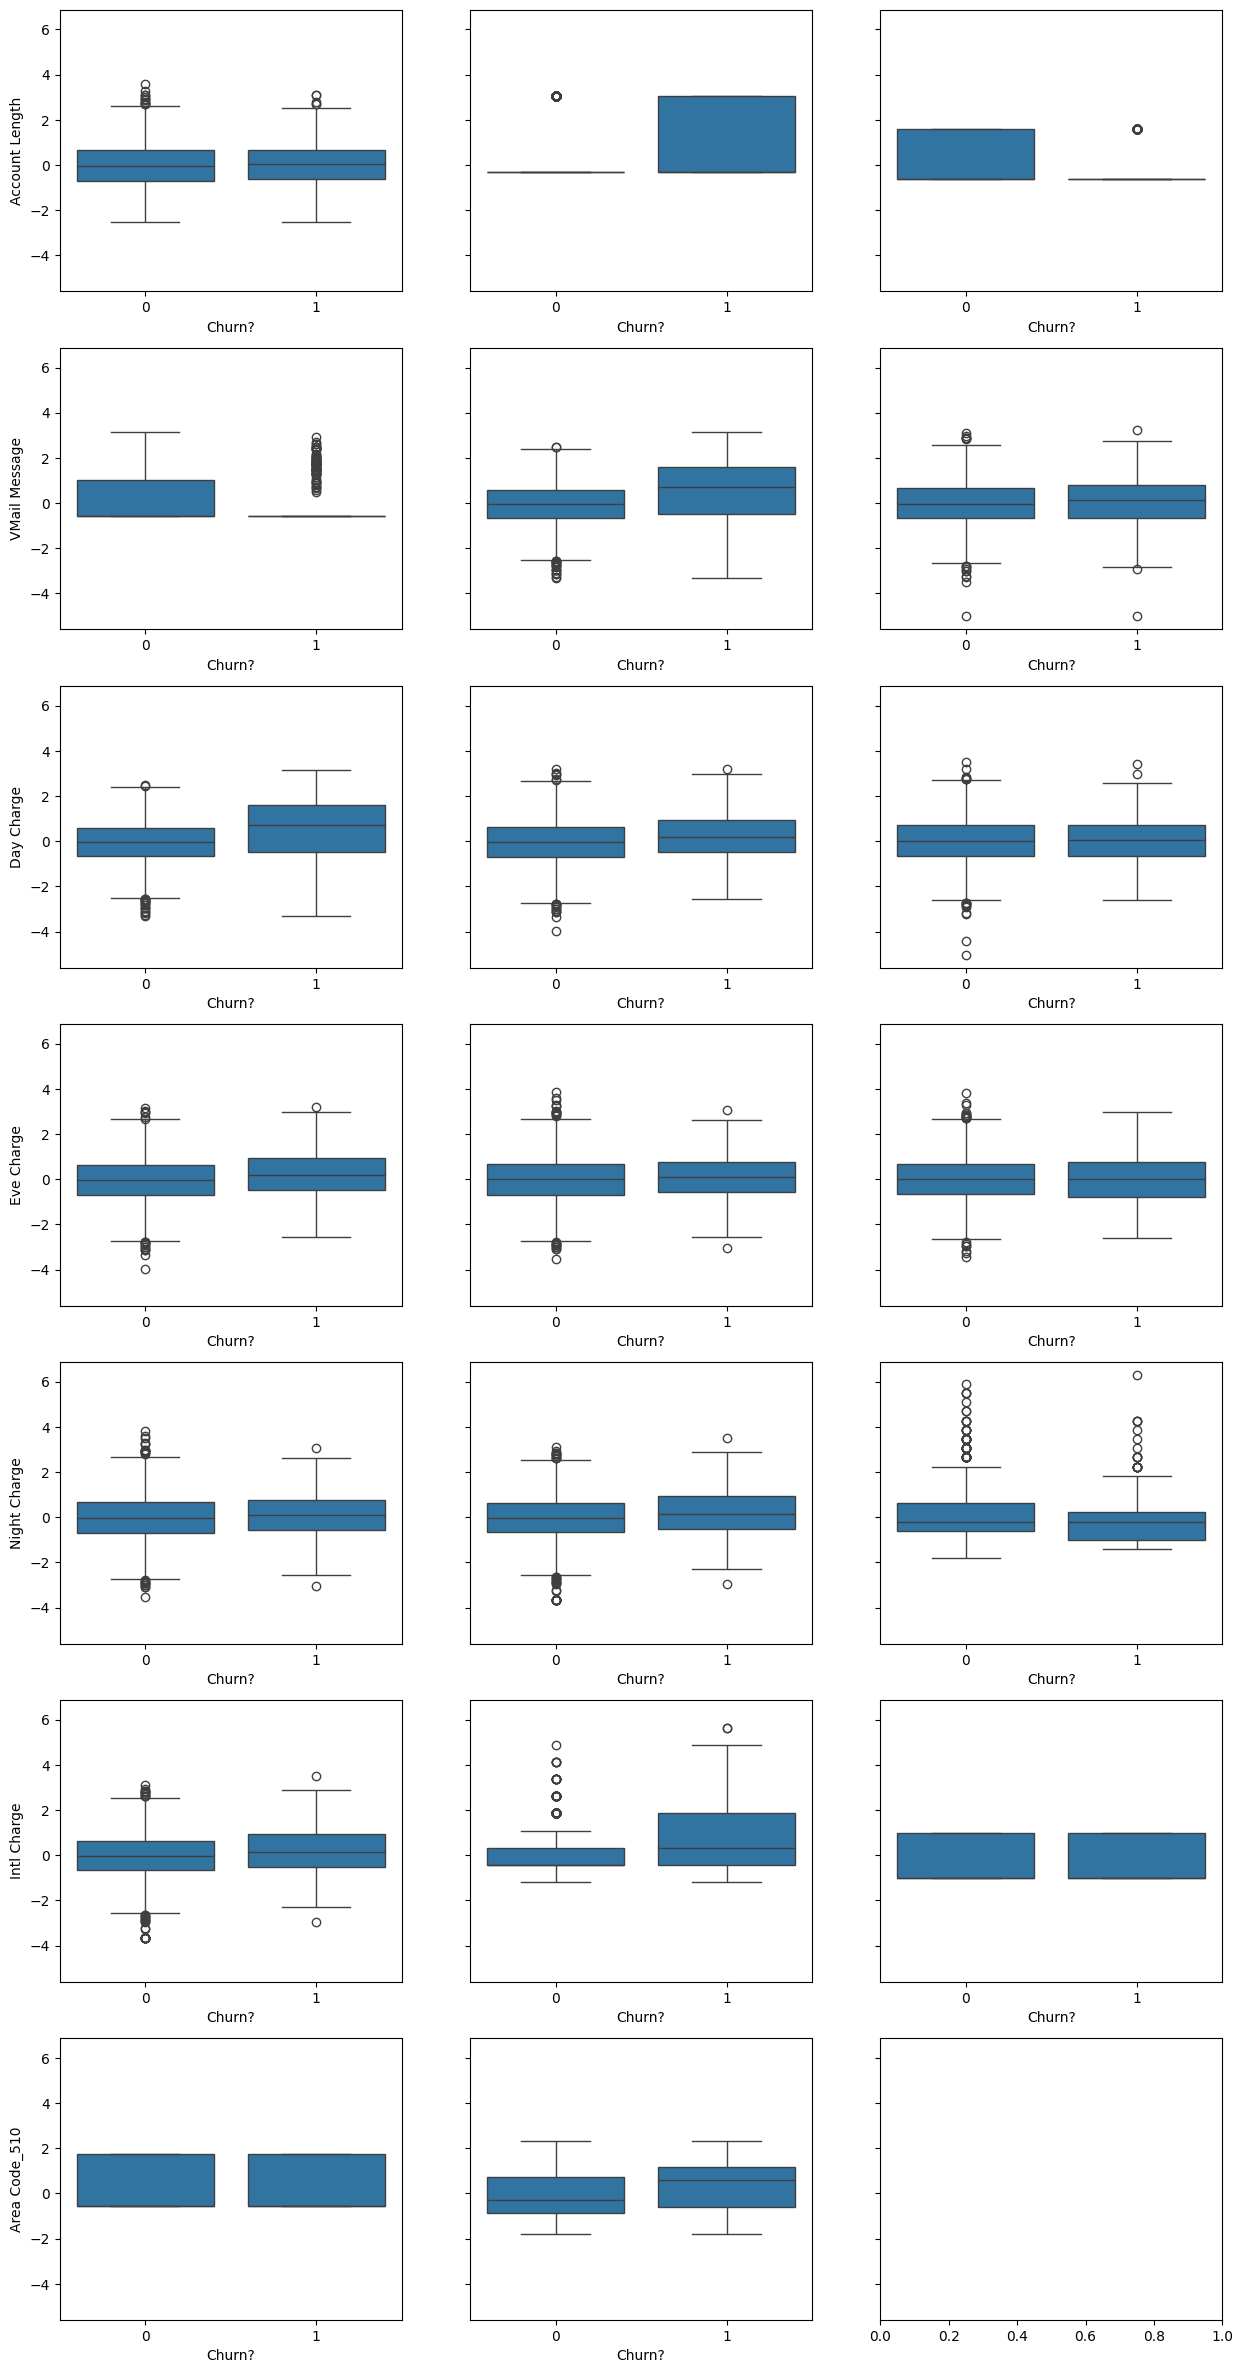

In [35]:
fig, axes = plt.subplots(n_rows, n_col, figsize=(15, 30), sharey=True)

r = 0
c = 0
for col in X_norm.columns:
    if c < (n_col - 1):
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
        
    elif c == (n_col - 1):
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
        r += 1
    else:
        c = 0
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
    c += 1

In [36]:
# tri croisé des var quali
for i in ("Int'l Plan","VMail Plan","Area Code_415","Area Code_510"):
    print(pd.crosstab(X_norm[i], y, normalize=0))

Churn?             0         1
Int'l Plan                    
-0.327580   0.885050  0.114950
 3.052685   0.575851  0.424149
Churn?             0         1
VMail Plan                    
-0.618396   0.832849  0.167151
 1.617086   0.913232  0.086768
Churn?                0         1
Area Code_415                    
-0.993123      0.852801  0.147199
 1.006925      0.857402  0.142598
Churn?                0         1
Area Code_510                    
-0.580468      0.856398  0.143602
 1.722747      0.851190  0.148810
